In [74]:
# Projet github : https://github.com/Quentinfln/ProjetChlordecone

In [46]:
# ============================================================
# PROJET DE SEMESTRE - CHLORDECONE
# Analyse et ingénierie des données en Python
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import geopandas as gpd
import contextily as ctx


In [47]:
# ------------------------------------------------------------
# CHARGEMENT DES DONNEES
# ------------------------------------------------------------

file_path = "BaseCLD2026.xlsx"
df_raw = pd.read_excel(file_path)

df = df_raw.copy()
df.columns = df.iloc[0]
df = df.drop(0).reset_index(drop=True)

# normalisation des noms de colonnes
df.columns = [str(col).strip().lower() for col in df.columns]

print("\nDimensions après correction de l'en-tête :", df.shape)
print("\nColonnes :")
print(df.columns.tolist())


Dimensions après correction de l'en-tête : (31126, 22)

Colonnes :
['id', 'annee', 'commu_lab', 'rain', 'sol_simple', 'type_sol', 'date_prelevement', 'date_enregistrement', 'date_analyse', 'operateur_chld', 'taux_chlordecone', 'operateur_5b', 'taux_5b_hydro', 'histobanane_histo_ban', 'mnt_tpi_mean', 'mnt_tri_mean', 'mnt_rugosite_mean', 'mnt_ombrage_mean', 'mnt_exposition_mean', 'mnt_pente_mean', 'x', 'y']


In [48]:
# ------------------------------------------------------------
# CONVERSION DES TYPES
# ------------------------------------------------------------

# dates
date_cols = ["date_prelevement", "date_enregistrement", "date_analyse"]
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce")

# colonnes numériques
num_cols_candidates = [
    "id", "annee", "taux_chlordecone", "taux_5b_hydro",
    "histobanane_histo_ban", "mnt_tpi_mean", "mnt_tri_mean",
    "mnt_rugosite_mean", "mnt_ombrage_mean", "mnt_exposition_mean",
    "mnt_pente_mean", "x", "y"
]

for col in num_cols_candidates:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

print("\nTypes de variables :")
print(df.dtypes)


Types de variables :
id                                int64
annee                             int64
commu_lab                        object
rain                             object
sol_simple                       object
type_sol                         object
date_prelevement         datetime64[ns]
date_enregistrement      datetime64[ns]
date_analyse             datetime64[ns]
operateur_chld                   object
taux_chlordecone                float64
operateur_5b                     object
taux_5b_hydro                   float64
histobanane_histo_ban           float64
mnt_tpi_mean                    float64
mnt_tri_mean                    float64
mnt_rugosite_mean               float64
mnt_ombrage_mean                float64
mnt_exposition_mean             float64
mnt_pente_mean                  float64
x                               float64
y                               float64
dtype: object



Nombre de valeurs manquantes par variable :
histobanane_histo_ban    17983
date_analyse              2702
type_sol                  2609
commu_lab                  298
sol_simple                  74
mnt_pente_mean              28
mnt_ombrage_mean            28
mnt_rugosite_mean           28
mnt_tri_mean                28
mnt_exposition_mean         28
mnt_tpi_mean                28
taux_5b_hydro               23
id                           0
annee                        0
rain                         0
taux_chlordecone             0
date_enregistrement          0
operateur_chld               0
date_prelevement             0
operateur_5b                 0
x                            0
y                            0
dtype: int64


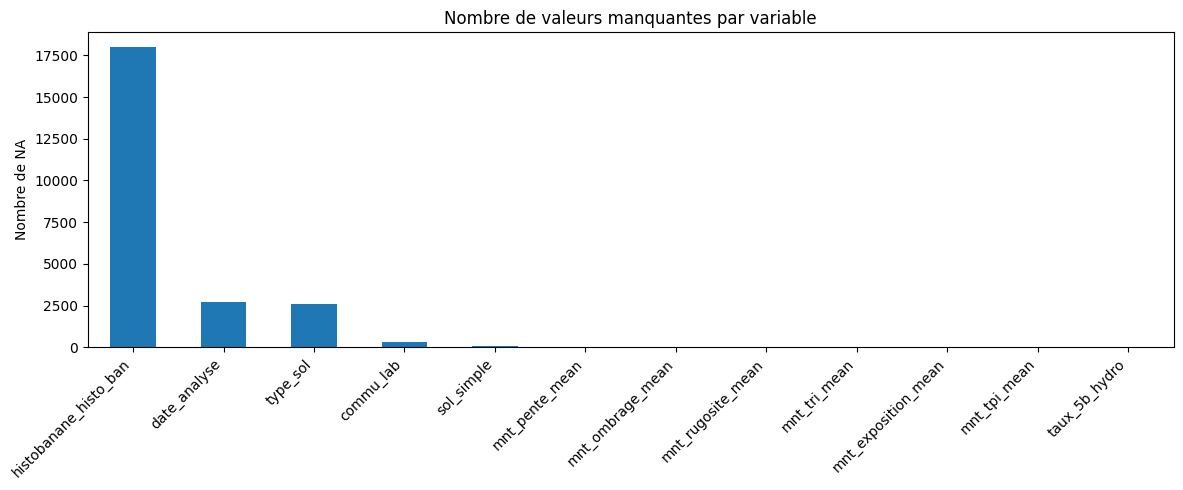

In [49]:
# ------------------------------------------------------------
# CONTROLE QUALITE / VALEURS MANQUANTES
# ------------------------------------------------------------

print("\nNombre de valeurs manquantes par variable :")
missing = df.isna().sum().sort_values(ascending=False)
print(missing)

# visualisation simple des valeurs manquantes
plt.figure(figsize=(12, 5))
missing[missing > 0].plot(kind="bar")
plt.title("Nombre de valeurs manquantes par variable")
plt.ylabel("Nombre de NA")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [50]:
# ------------------------------------------------------------
# DATA CLEANING REPRODUCTIBLE
# ------------------------------------------------------------

# suppression des doublons exacts
n_before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
n_after = len(df)

print(f"\nDoublons supprimés : {n_before - n_after}")

# nettoyage de variables textuelles
text_cols = ["commu_lab", "rain", "sol_simple", "type_sol", "operateur_chld", "operateur_5b"]
for col in text_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()

# remplacement de chaînes vides par NaN
df = df.replace(r"^\s*$", np.nan, regex=True)

# colonnes numériques
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# remplacer les valeurs infinies par NaN
df[numeric_cols] = df[numeric_cols].replace([np.inf, -np.inf], np.nan)

# optionnel : repérer les colonnes problématiques
print("\nNombre de valeurs infinies par colonne numérique :")
print(np.isinf(df[numeric_cols]).sum())

# imputation des variables numériques par la médiane
imputer = SimpleImputer(strategy="median")
df[numeric_cols] = imputer.fit_transform(df[numeric_cols])



Doublons supprimés : 8

Nombre de valeurs infinies par colonne numérique :
id                       0
annee                    0
taux_chlordecone         0
taux_5b_hydro            0
histobanane_histo_ban    0
mnt_tpi_mean             0
mnt_tri_mean             0
mnt_rugosite_mean        0
mnt_ombrage_mean         0
mnt_exposition_mean      0
mnt_pente_mean           0
x                        0
y                        0
dtype: int64


In [51]:
# ------------------------------------------------------------
# TRANSFORMATION DES VARIABLES
# ------------------------------------------------------------

# variables temporelles
df["annee_prelevement"] = df["date_prelevement"].dt.year
df["mois_prelevement"] = df["date_prelevement"].dt.month
df["jour_prelevement"] = df["date_prelevement"].dt.day

# délai entre prélèvement, enregistrement et analyse
df["delai_prelevement_enregistrement"] = (
    df["date_enregistrement"] - df["date_prelevement"]
).dt.days

df["delai_enregistrement_analyse"] = (
    df["date_analyse"] - df["date_enregistrement"]
).dt.days

df["delai_total_analyse"] = (
    df["date_analyse"] - df["date_prelevement"]
).dt.days

# recodage d'un niveau de contamination
# seuils choisis ici en quartiles pour produire une catégorisation exploitable
q1 = df["taux_chlordecone"].quantile(0.25)
q3 = df["taux_chlordecone"].quantile(0.75)

def niveau_contamination(x):
    if pd.isna(x):
        return "inconnu"
    elif x <= q1:
        return "faible"
    elif x <= q3:
        return "moyenne"
    else:
        return "forte"

df["niveau_contamination"] = df["taux_chlordecone"].apply(niveau_contamination)

print("\nRépartition du niveau de contamination :")
print(df["niveau_contamination"].value_counts())


Répartition du niveau de contamination :
niveau_contamination
moyenne    15541
faible      7797
forte       7780
Name: count, dtype: int64


In [52]:
# ------------------------------------------------------------
# MANIPULATION TABULAIRE
# group_by, summarise, order_by, filter, mutate
# ------------------------------------------------------------

# contamination moyenne par commune
conta_par_commune = (
    df.groupby("commu_lab", dropna=False)
      .agg(
          nb_obs=("id", "count"),
          taux_chlordecone_moyen=("taux_chlordecone", "mean"),
          taux_chlordecone_mediane=("taux_chlordecone", "median"),
          taux_5b_hydro_moyen=("taux_5b_hydro", "mean")
      )
      .sort_values("taux_chlordecone_moyen", ascending=False)
)

print("\nTop 10 communes les plus contaminées en moyenne :")
print(conta_par_commune.head(10))

# filtrage des parcelles fortement contaminées
df_forte_conta = df[df["niveau_contamination"] == "forte"].copy()
print("\nDimensions des parcelles fortement contaminées :", df_forte_conta.shape)

# analyse par type de sol
conta_par_sol = (
    df.groupby("sol_simple", dropna=False)
      .agg(
          nb_obs=("id", "count"),
          taux_moyen=("taux_chlordecone", "mean"),
          taux_mediane=("taux_chlordecone", "median")
      )
      .sort_values("taux_moyen", ascending=False)
)

print("\nContamination moyenne par type de sol :")
print(conta_par_sol.head(10))

# analyse par groupe de pluie
conta_par_rain = (
    df.groupby("rain", dropna=False)
      .agg(
          nb_obs=("id", "count"),
          taux_moyen=("taux_chlordecone", "mean")
      )
      .sort_values("taux_moyen", ascending=False)
)

print("\nContamination moyenne par groupe de pluviométrie :")
print(conta_par_rain)



Top 10 communes les plus contaminées en moyenne :
                 nb_obs  taux_chlordecone_moyen  taux_chlordecone_mediane  \
commu_lab                                                                   
MORNE-ROUGE(LE)    3725                2.800495                    2.7580   
GRAND'RIVIERE       125                1.839945                    0.3363   
MACOUBA             698                1.696628                    1.5000   
BASSE-POINTE        992                1.381041                    0.0900   
TRINITE(LA)        1101                0.684156                    0.0600   
MARIGOT(LE)         475                0.613124                    0.1250   
LORRAIN(LE)        1755                0.574929                    0.1850   
SAINT-PIERRE        339                0.561331                    0.0053   
GROS-MORNE         2093                0.546698                    0.0033   
LAMENTIN(LE)       1930                0.442285                    0.0033   

                 taux_5b

In [53]:
# ------------------------------------------------------------
# EXEMPLES DE RECHERCHE / INDEXATION / MODIFICATION
# ------------------------------------------------------------

# rechercher une parcelle spécifique
exemple_id = df["id"].iloc[0]
print("\nExemple de recherche d'une parcelle par ID :", exemple_id)
print(df[df["id"] == exemple_id].head())

# modification d'une ligne : exemple pédagogique
df.loc[df["taux_chlordecone"] < 0, "taux_chlordecone"] = np.nan

# création d'une nouvelle colonne normalisée
df["ratio_chlordecone_5b"] = df["taux_chlordecone"] / (df["taux_5b_hydro"] + 1e-6)


Exemple de recherche d'une parcelle par ID : 20143.0
        id   annee   commu_lab       rain sol_simple  \
0  20143.0  2010.0  GROS-MORNE  2000-3000    Andosol   
1  20143.0  2010.0  GROS-MORNE  2000-3000    Andosol   
2  20143.0  2010.0  GROS-MORNE  2000-3000    Andosol   
3  20143.0  2010.0  GROS-MORNE  2000-3000    Andosol   
4  20143.0  2010.0  GROS-MORNE  2000-3000    Andosol   

                                            type_sol date_prelevement  \
0  Intergrades Sols … allophane relativement ‚vol...       2007-05-24   
1  Intergrades Sols … allophane relativement ‚vol...       2007-05-24   
2  Intergrades Sols … allophane relativement ‚vol...       2007-05-24   
3  Intergrades Sols … allophane relativement ‚vol...       2007-05-24   
4  Intergrades Sols … allophane relativement ‚vol...       2007-05-24   

  date_enregistrement date_analyse operateur_chld  ...  mnt_pente_mean  \
0          2007-05-24   2007-05-24              =  ...       39.043098   
1          2007-05-24 

In [54]:
# ------------------------------------------------------------
# JOINTURES (illustration demandée dans le projet)
# ------------------------------------------------------------
# Comme aucun fichier externe supplémentaire n'a été fourni,
# on crée une petite table agrégée pour illustrer left/right/inner/full join.

table_commune = (
    df.groupby("commu_lab", dropna=False)
      .agg(nb_parcelles=("id", "count"))
      .reset_index()
)

table_risque = (
    df.groupby("commu_lab", dropna=False)
      .agg(risque_moyen=("taux_chlordecone", "mean"))
      .reset_index()
)

left_join_demo = pd.merge(table_commune, table_risque, on="commu_lab", how="left")
right_join_demo = pd.merge(table_commune, table_risque, on="commu_lab", how="right")
inner_join_demo = pd.merge(table_commune, table_risque, on="commu_lab", how="inner")
full_join_demo = pd.merge(table_commune, table_risque, on="commu_lab", how="outer")

print("\nDimensions jointures :")
print("left join  :", left_join_demo.shape)
print("right join :", right_join_demo.shape)
print("inner join :", inner_join_demo.shape)
print("full join  :", full_join_demo.shape)


Dimensions jointures :
left join  : (36, 3)
right join : (36, 3)
inner join : (36, 3)
full join  : (36, 3)


In [55]:
# ------------------------------------------------------------
# STRUCTURES DE CONTROLE, BOUCLES, APPLY
# ------------------------------------------------------------

# if / else via fonction
def classer_pente(x):
    if pd.isna(x):
        return "inconnue"
    elif x < 5:
        return "faible"
    elif x < 15:
        return "moderee"
    else:
        return "forte"

df["classe_pente"] = df["mnt_pente_mean"].apply(classer_pente)

# boucle sur plusieurs variables pour afficher leurs moyennes
vars_a_resume = ["taux_chlordecone", "taux_5b_hydro", "mnt_pente_mean", "mnt_tri_mean"]

print("\nRésumé de quelques variables numériques :")
for var in vars_a_resume:
    if var in df.columns:
        print(f"{var} -> moyenne = {df[var].mean():.4f}, médiane = {df[var].median():.4f}")

# apply sur une ligne
def score_risque(row):
    score = 0
    if row["taux_chlordecone"] > df["taux_chlordecone"].median():
        score += 1
    if row["mnt_pente_mean"] > df["mnt_pente_mean"].median():
        score += 1
    if row["mnt_tri_mean"] > df["mnt_tri_mean"].median():
        score += 1
    return score

df["score_risque"] = df.apply(score_risque, axis=1)

print("\nDistribution du score de risque :")
print(df["score_risque"].value_counts().sort_index())


Résumé de quelques variables numériques :
taux_chlordecone -> moyenne = 0.6672, médiane = 0.0033
taux_5b_hydro -> moyenne = 4.4478, médiane = 0.0033
mnt_pente_mean -> moyenne = 20.2660, médiane = 17.9025
mnt_tri_mean -> moyenne = 4.3131, médiane = 3.8224

Distribution du score de risque :
score_risque
0    6853
1    8788
2    8638
3    6839
Name: count, dtype: int64


In [56]:
# ------------------------------------------------------------
# EXPLORATION DES MODALITES
# ------------------------------------------------------------

print("\nNombre de communes :", df["commu_lab"].nunique())
print("Nombre de types de sols simples :", df["sol_simple"].nunique())
print("Nombre de groupes de pluie :", df["rain"].nunique())

print("\nTop communes :")
print(df["commu_lab"].value_counts().head(10))

print("\nTop types de sols :")
print(df["sol_simple"].value_counts().head(10))


Nombre de communes : 36
Nombre de types de sols simples : 8
Nombre de groupes de pluie : 6

Top communes :
commu_lab
MORNE-ROUGE(LE)    3725
GROS-MORNE         2093
LAMENTIN(LE)       1930
SAINT-JOSEPH       1879
LORRAIN(LE)        1755
ROBERT(LE)         1728
DUCOS              1591
FRANCOIS(LE)       1483
SAINTE-MARIE       1406
SAINT-ESPRIT       1393
Name: count, dtype: int64

Top types de sols :
sol_simple
Andosol                10946
Vertisol                6921
Ferralsol               5182
Nitisol                 3062
No data                 2617
Alluvium, Colluvium     1604
Urban area               712
nan                       74
Name: count, dtype: int64


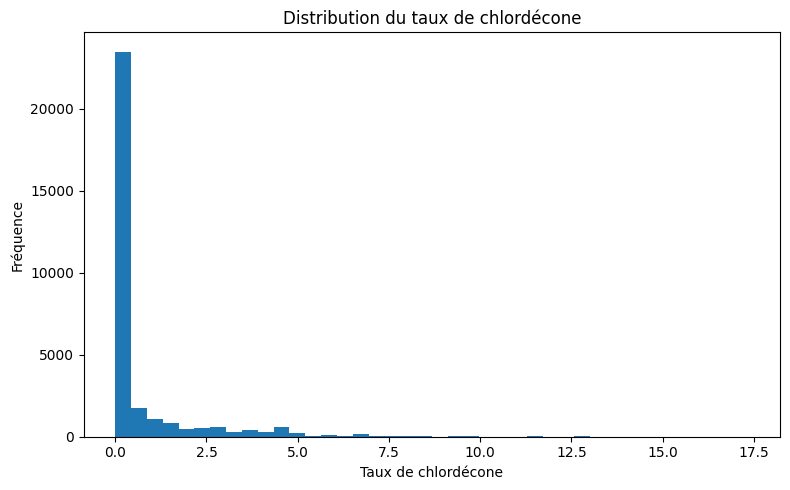

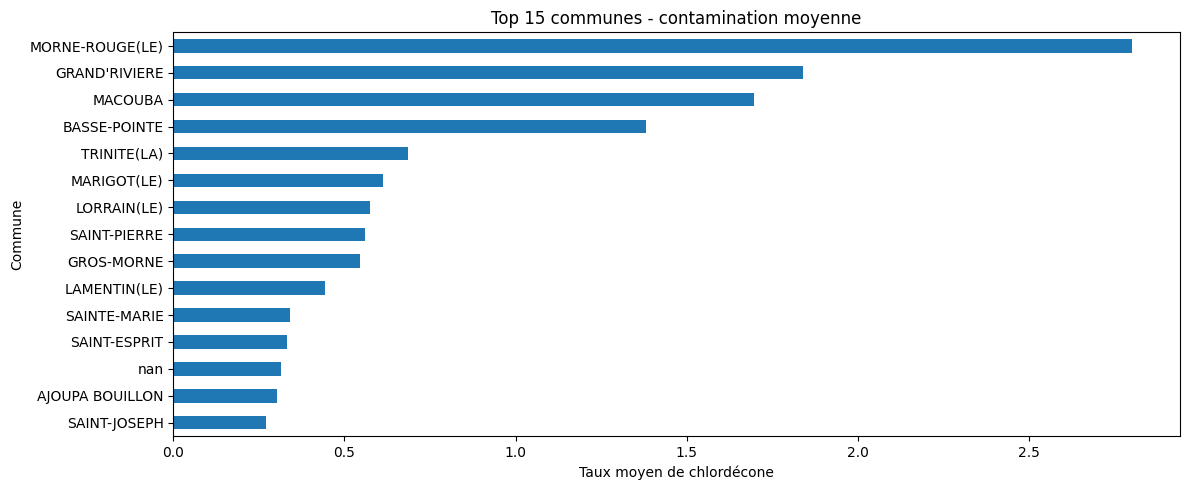

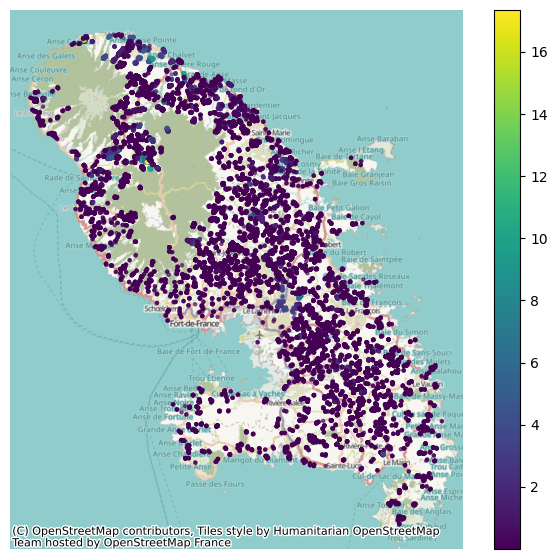

In [61]:
# ------------------------------------------------------------
# VISUALISATIONS
# ------------------------------------------------------------

# histogramme taux de chlordécone
plt.figure(figsize=(8, 5))
df["taux_chlordecone"].dropna().plot(kind="hist", bins=40)
plt.title("Distribution du taux de chlordécone")
plt.xlabel("Taux de chlordécone")
plt.ylabel("Fréquence")
plt.tight_layout()
plt.show()

# contamination moyenne par commune (top 15)
plt.figure(figsize=(12, 5))
conta_par_commune["taux_chlordecone_moyen"].head(15).sort_values().plot(kind="barh")
plt.title("Top 15 communes - contamination moyenne")
plt.xlabel("Taux moyen de chlordécone")
plt.ylabel("Commune")
plt.tight_layout()
plt.show()

# Carte spatiale avec fond OpenStreetMap
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["x"], df["y"]),
    crs="EPSG:32620"  # UTM zone 20N (Guadeloupe/Martinique)
)

gdf = gdf.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(8, 7))

gdf.plot(
    ax=ax,
    column="taux_chlordecone",
    markersize=5,
    alpha=0.6,
    legend=True
)

ctx.add_basemap(ax)

ax.set_axis_off()
plt.show()



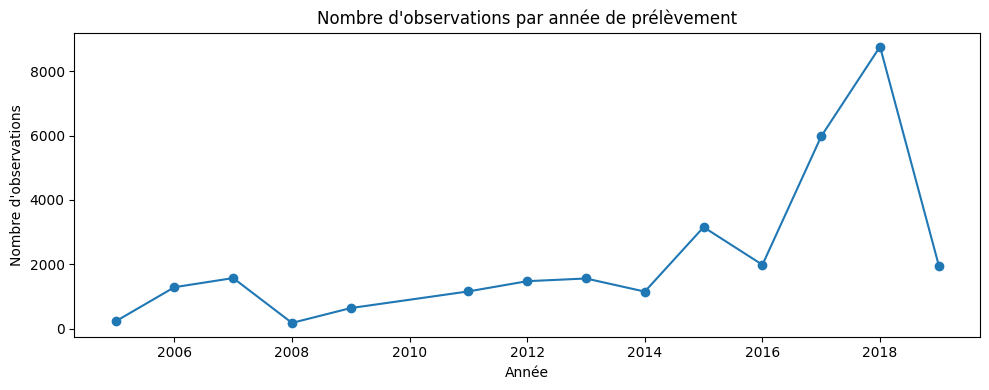


INTERPRÉTATION :
- Ce graphique permet d’observer l’évolution du volume de prélèvements au fil du temps.



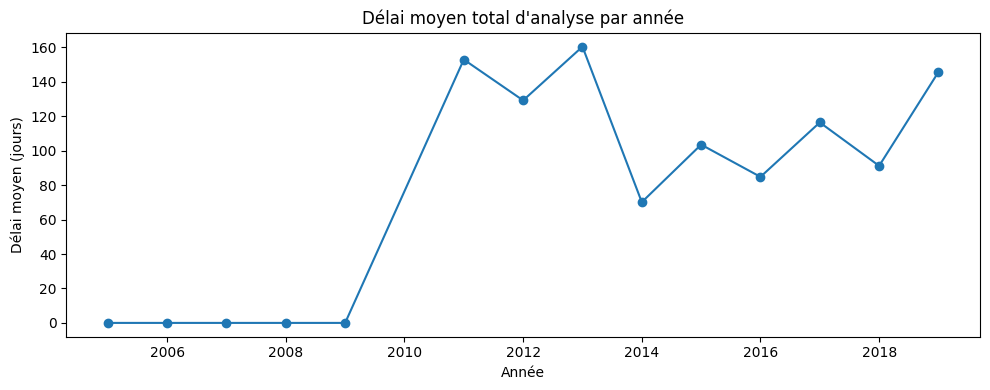


INTERPRÉTATION :
- Ce graphique mesure la performance du processus d’analyse des échantillons.



In [68]:
# ------------------------------------------------------------
# ANALYSE TEMPORELLE
# ------------------------------------------------------------

# nombre d'observations par année de prélèvement
obs_par_annee = df["annee_prelevement"].value_counts().sort_index()

plt.figure(figsize=(10, 4))
obs_par_annee.plot(marker="o")
plt.title("Nombre d'observations par année de prélèvement")
plt.xlabel("Année")
plt.ylabel("Nombre d'observations")
plt.tight_layout()
plt.show()

print("""
INTERPRÉTATION :
- Ce graphique permet d’observer l’évolution du volume de prélèvements au fil du temps.
""")


# délai moyen d'analyse par année
delai_par_annee = (
    df.groupby("annee_prelevement")["delai_total_analyse"]
      .mean()
)

plt.figure(figsize=(10, 4))
delai_par_annee.plot(marker="o")
plt.title("Délai moyen total d'analyse par année")
plt.xlabel("Année")
plt.ylabel("Délai moyen (jours)")
plt.tight_layout()
plt.show()

print("""
INTERPRÉTATION :
- Ce graphique mesure la performance du processus d’analyse des échantillons.
""")


Variance expliquée par composante :
CP1: 0.3718
CP2: 0.1809
CP3: 0.1296
CP4: 0.1246
CP5: 0.1190
CP6: 0.0660
CP7: 0.0046
CP8: 0.0033


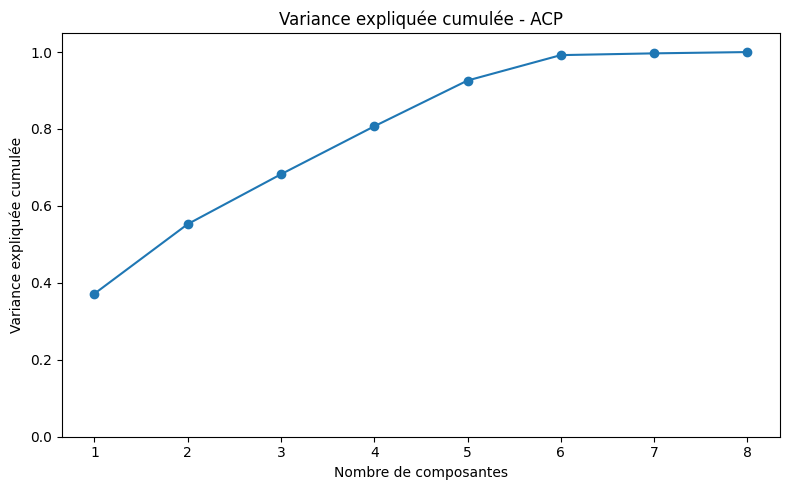


INTERPRÉTATION :
- Ce graphique permet de déterminer combien de composantes principales sont nécessaires pour expliquer la variance des données.



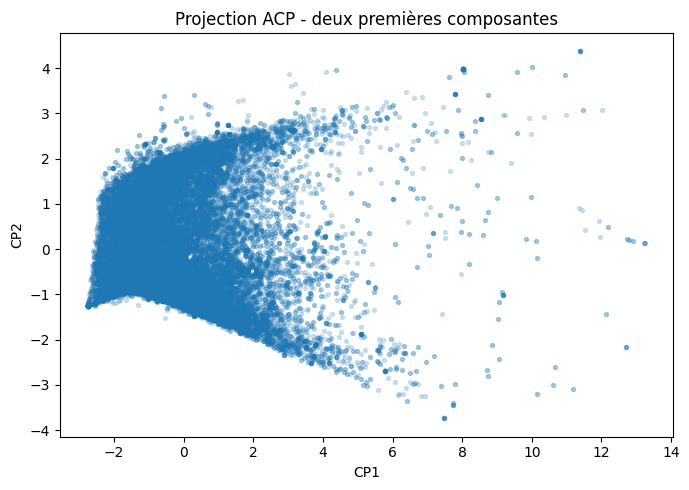


INTERPRÉTATION :
- Cette projection permet de visualiser la structure globale des données.


Loadings ACP :
                          CP1       CP2
taux_chlordecone     0.038145  0.145309
taux_5b_hydro        0.009619 -0.012775
mnt_tpi_mean         0.027380 -0.067051
mnt_tri_mean         0.572125  0.021967
mnt_rugosite_mean    0.573495  0.021726
mnt_ombrage_mean    -0.107422  0.689134
mnt_exposition_mean  0.053559  0.705825
mnt_pente_mean       0.571901  0.013312

INTERPRÉTATION :
- Les loadings indiquent l’importance de chaque variable dans la construction des axes.
- Une valeur élevée (positive ou négative) signifie que la variable contribue fortement à la composante.
- Cela permet d’interpréter les axes :
    → CP1 peut représenter un gradient de contamination ou de topographie
    → CP2 peut représenter une autre dimension environnementale



In [70]:
# ------------------------------------------------------------
# ACP (ANALYSE EN COMPOSANTES PRINCIPALES)
# ------------------------------------------------------------

features_pca = [
    "taux_chlordecone",
    "taux_5b_hydro",
    "mnt_tpi_mean",
    "mnt_tri_mean",
    "mnt_rugosite_mean",
    "mnt_ombrage_mean",
    "mnt_exposition_mean",
    "mnt_pente_mean"
]

features_pca = [col for col in features_pca if col in df.columns]

X = df[features_pca].copy()

# sécurité supplémentaire
X = X.replace([np.inf, -np.inf], np.nan)

# imputation si besoin
imp_pca = SimpleImputer(strategy="median")
X_imputed = imp_pca.fit_transform(X)

# standardisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# ACP
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

variance_expliquee = pca.explained_variance_ratio_
variance_cumulee = np.cumsum(variance_expliquee)

print("\nVariance expliquée par composante :")
for i, v in enumerate(variance_expliquee, start=1):
    print(f"CP{i}: {v:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(variance_cumulee) + 1), variance_cumulee, marker="o")
plt.title("Variance expliquée cumulée - ACP")
plt.xlabel("Nombre de composantes")
plt.ylabel("Variance expliquée cumulée")
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

print("""
INTERPRÉTATION :
- Ce graphique permet de déterminer combien de composantes principales sont nécessaires pour expliquer la variance des données.
""")


# projection sur les deux premières composantes
plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.2, s=8)
plt.title("Projection ACP - deux premières composantes")
plt.xlabel("CP1")
plt.ylabel("CP2")
plt.tight_layout()
plt.show()

print("""
INTERPRÉTATION :
- Cette projection permet de visualiser la structure globale des données.
""")


# contributions des variables à CP1 et CP2
loadings = pd.DataFrame(
    pca.components_.T,
    index=features_pca,
    columns=[f"CP{i}" for i in range(1, len(features_pca) + 1)]
)

print("\nLoadings ACP :")
print(loadings[["CP1", "CP2"]])

print("""
INTERPRÉTATION :
- Les loadings indiquent l’importance de chaque variable dans la construction des axes.
- Une valeur élevée (positive ou négative) signifie que la variable contribue fortement à la composante.
- Cela permet d’interpréter les axes :
    → CP1 peut représenter un gradient de contamination ou de topographie
    → CP2 peut représenter une autre dimension environnementale
""")


Effectifs par cluster :
cluster
0     9340
1    21640
2      138
Name: count, dtype: int64

INTERPRÉTATION :
- Cette étape permet de segmenter les parcelles en groupes homogènes.


Résumé des clusters :
         nb_obs  chlordecone_moy   hydro_moy  pente_moy   tri_moy
cluster                                                          
0          9340         0.691296    0.017947  35.847890  7.517688
1         21640         0.658336    0.017474  13.528012  2.928177
2           138         0.421568  999.000000  22.265611  4.588182

INTERPRÉTATION :
- Permet de caractériser chaque cluster.
- On peut identifier :
    → les clusters à forte contamination
    → les conditions environnementales associées
- Le cluster avec le taux moyen de chlordécone le plus élevé correspond aux zones les plus à risque.



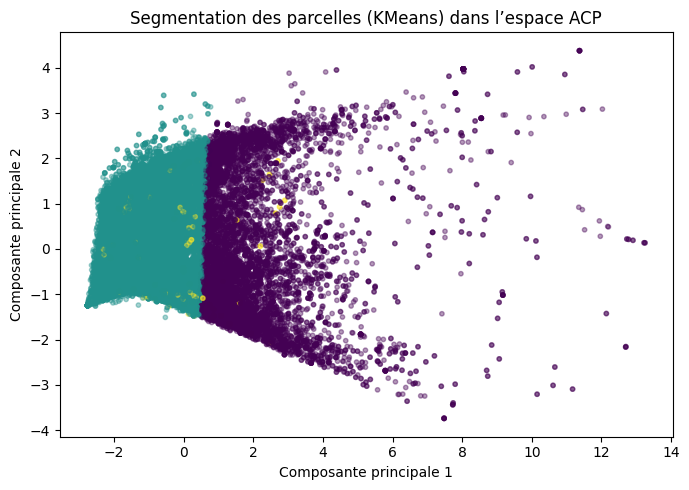


INTERPRÉTATION :
- Cette visualisation permet de voir la séparation des clusters.



In [72]:
# ------------------------------------------------------------
# CLUSTERING KMEANS
# ------------------------------------------------------------

# choix simple de k = 3 pour une première segmentation
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df["cluster"] = clusters

print("\nEffectifs par cluster :")
print(df["cluster"].value_counts().sort_index())

print("""
INTERPRÉTATION :
- Cette étape permet de segmenter les parcelles en groupes homogènes.
""")


# résumé des clusters
cluster_summary = (
    df.groupby("cluster")
      .agg(
          nb_obs=("id", "count"),
          chlordecone_moy=("taux_chlordecone", "mean"),
          hydro_moy=("taux_5b_hydro", "mean"),
          pente_moy=("mnt_pente_mean", "mean"),
          tri_moy=("mnt_tri_mean", "mean")
      )
      .sort_index()
)

print("\nRésumé des clusters :")
print(cluster_summary)

print("""
INTERPRÉTATION :
- Permet de caractériser chaque cluster.
- On peut identifier :
    → les clusters à forte contamination
    → les conditions environnementales associées
- Le cluster avec le taux moyen de chlordécone le plus élevé correspond aux zones les plus à risque.
""")


# visualisation dans l’espace ACP
plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df["cluster"], alpha=0.4, s=10)

plt.title("Segmentation des parcelles (KMeans) dans l’espace ACP")
plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")

plt.tight_layout()
plt.show()

print("""
INTERPRÉTATION :
- Cette visualisation permet de voir la séparation des clusters.
""")

In [73]:
# ------------------------------------------------------------
# INSIGHTS DECISIONNELS
# ------------------------------------------------------------

print("\n================ INSIGHTS =================")
print("1. Les communes peuvent être classées selon leur niveau moyen de contamination.")
print("2. Les types de sol et les groupes de pluie semblent influencer les taux observés.")
print("3. Les variables topographiques structurent une partie de l'hétérogénéité des parcelles.")
print("4. Le clustering permet d'identifier des profils environnementaux distincts.")
print("5. Les parcelles du cluster avec le taux moyen de chlordécone le plus élevé doivent être priorisées pour la surveillance.")

cluster_risque_max = cluster_summary["chlordecone_moy"].idxmax()
print(f"\nCluster le plus à risque : {cluster_risque_max}")

communes_prioritaires = conta_par_commune.head(10)
print("\nCommunes prioritaires (top 10 contamination moyenne) :")
print(communes_prioritaires)


================ INSIGHTS =================
1. Les communes peuvent être classées selon leur niveau moyen de contamination.
2. Les types de sol et les groupes de pluie semblent influencer les taux observés.
3. Les variables topographiques structurent une partie de l'hétérogénéité des parcelles.
4. Le clustering permet d'identifier des profils environnementaux distincts.
5. Les parcelles du cluster avec le taux moyen de chlordécone le plus élevé doivent être priorisées pour la surveillance.

Cluster le plus à risque : 0

Communes prioritaires (top 10 contamination moyenne) :
                 nb_obs  taux_chlordecone_moyen  taux_chlordecone_mediane  \
commu_lab                                                                   
MORNE-ROUGE(LE)    3725                2.800495                    2.7580   
GRAND'RIVIERE       125                1.839945                    0.3363   
MACOUBA             698                1.696628                    1.5000   
BASSE-POINTE        992          